In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import os
import cv2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [6]:
data_path = "./Dataset_BUSI_with_GT"
image_size = (150, 150)
classes = ["benign", "malignant", "normal"]

X, y = [], []
for idx, category in enumerate(classes):
    category_path = os.path.join(data_path, category)
    for file in os.listdir(category_path):
        file_path = os.path.join(category_path, file)
        try:
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            img_resized = cv2.resize(img, image_size)
            X.append(img_resized)
            y.append(idx)
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")




In [7]:

X = np.array(X, dtype=np.float32) / 255.0  
y = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X = X.reshape(-1, 150, 150, 1)

y_categorical = to_categorical(y_encoded)

print(f"Dataset Loaded: {X.shape} images, {y_categorical.shape} labels")

Dataset Loaded: (1578, 150, 150, 1) images, (1578, 3) labels


In [8]:

X_flattened = X.reshape(X.shape[0], -1)  


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flattened, y)


pca = PCA(n_components=1500)
X_pca = pca.fit_transform(X_resampled)

X_resampled = X_pca.reshape(X_pca.shape[0], 10, 150, 1) 


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import accuracy_score, classification_report


model = Sequential([
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.01), input_shape=(10, 150, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(len(np.unique(y_train)), activation='softmax')  
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), 
                    batch_size=32, callbacks=[early_stopping])

y_pred = np.argmax(model.predict(X_test), axis=1)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Epoch 1/20


C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6889 - loss: 6.1526 - val_accuracy: 0.5551 - val_loss: 4.1388
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8541 - loss: 3.2214 - val_accuracy: 0.3421 - val_loss: 3.6155
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8968 - loss: 2.1622 - val_accuracy: 0.5252 - val_loss: 3.1380
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9063 - loss: 1.6461 - val_accuracy: 0.3477 - val_loss: 2.6185
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9322 - loss: 1.2486 - val_accuracy: 0.6262 - val_loss: 1.6674
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9434 - loss: 1.0250 - val_accuracy: 0.6393 - val_loss: 1.6288
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9592 - loss: 0.8642 - val_accuracy: 0.8860 - val_loss: 0.9401
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9566 - loss: 0.7603 - val_accuracy: 0.8935 - val_loss: 0.

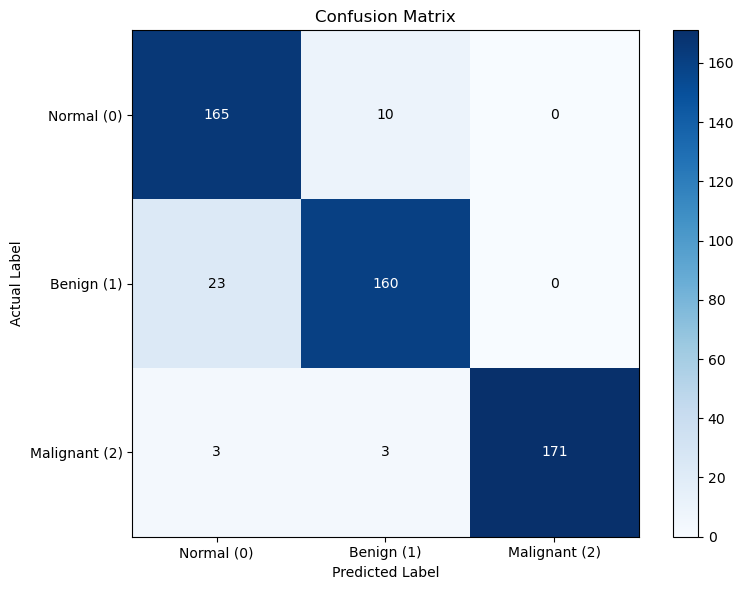

In [24]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))  
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()


tick_marks = np.arange(len(np.unique(y_test))) 
plt.xticks(tick_marks, labels=["Normal (0)", "Benign (1)", "Malignant (2)"], rotation=0)
plt.yticks(tick_marks, labels=["Normal (0)", "Benign (1)", "Malignant (2)"])


thresh = conf_matrix.max() / 2. 
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()



In [21]:
model.save("cnn_model_91acc.h5")  